In [9]:
import os
import torch
import timm
import torch.nn as nn
import pandas as pd
import numpy as np
from tqdm import tqdm
from PIL import Image
import seaborn as sns
import matplotlib.pyplot as plt
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, recall_score, confusion_matrix

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"System Check: Using {device.type.upper()}")

System Check: Using CUDA


In [11]:
def generate_split_manifest(root_dir, save_path="dataset_splits.xlsx"):
    print("------------------------------------")
    print("Generating new manifest....")
    data = []

    for root, _, files in os.walk(root_dir):
        for file in files:
            if file.endswith('.png'):
                file_path = os.path.join(root, file)
                parts = os.path.normpath(file_path).split(os.sep)

                label_str = parts[-6]
                tumor_type = parts[-4]
                patient_id = parts[-3]
                magnification = parts[-2]

                data.append({
                    'image_path': file_path,
                    'patient_id': patient_id,
                    'tumor_type': tumor_type,
                    'magnification': magnification,
                    'label': 0 if label_str == 'benign' else 1
                })

    df = pd.DataFrame(data)
    patient_labels = df.groupby('patient_id')['label'].first()

    benign_patients    = patient_labels[patient_labels == 0].index.tolist()
    malignant_patients = patient_labels[patient_labels == 1].index.tolist()

    random.seed(42)
    random.shuffle(benign_patients)
    random.shuffle(malignant_patients)

    def split_patients(patient_list):
        n = len(patient_list)
        train_end = int(n * 0.70)
        val_end   = train_end + int(n * 0.15)

        train_set = set(patient_list[:train_end])
        val_set   = set(patient_list[train_end:val_end])
        test_set  = set(patient_list[val_end:])

        return train_set, val_set, test_set

    b_train, b_val, b_test = split_patients(benign_patients)
    m_train, m_val, m_test = split_patients(malignant_patients)

    train_patients = b_train.union(m_train)
    val_patients   = b_val.union(m_val)

    def assign_split(pid):
        if pid in train_patients: return 'train'
        if pid in val_patients: return 'val'
        return 'test'

    df['split'] = df['patient_id'].apply(assign_split)

    train_patients = df[df['split'] == 'train']['patient_id'].nunique()
    val_patients   = df[df['split'] == 'val']['patient_id'].nunique()
    test_patients  = df[df['split'] == 'test']['patient_id'].nunique()

    print(f"Total Patient Split -> Train: {train_patients} | "
          f"Val: {val_patients} | Test: {test_patients}")
    print("Image Level Summary:")
    print(df.groupby(['split', 'label']).size().unstack(fill_value=0))

    df.to_excel(save_path, index=False)
    print(f"\nManifest saved to: {save_path}")

manifest_path = "dataset_splits.xlsx"
print("Loading Dataset Manifest...")
try:
    df = pd.read_excel(manifest_path)
    train_patients = df[df['split'] == 'train']['patient_id'].nunique()
    val_patients   = df[df['split'] == 'val']['patient_id'].nunique()
    test_patients  = df[df['split'] == 'test']['patient_id'].nunique()
    print(f"Total Patient Split -> Train: {train_patients} | "
          f"Val: {val_patients} | Test: {test_patients}")
    print("Image Level Summary:")
    print(df.groupby(['split', 'label']).size().unstack(fill_value=0))
except FileNotFoundError:
    print("Dataset Manifest not found.")
    generate_split_manifest("BreaKHis_v1", manifest_path)
    df = pd.read_excel(manifest_path)

Loading Dataset Manifest...
Total Patient Split -> Train: 56 | Val: 11 | Test: 15
Image Level Summary:
label     0     1
split            
test    508   930
train  1633  3686
val     339   813


In [12]:
class BreaKHisDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.loc[idx, 'image_path']
        label = self.dataframe.loc[idx, 'label']

        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32)

In [13]:
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_df       = df[df['split'] == 'test'].copy().reset_index(drop=True)
test_dataset  = BreaKHisDataset(test_df,  transform=test_transform)

print(f"Test: {len(test_df)} images ({test_df['patient_id'].nunique()} patients)")

batches = 32
test_loader = DataLoader(
        test_dataset,
        batch_size=batches,
        shuffle=False,
        pin_memory=True
    )

Test: 1438 images (15 patients)


In [14]:
#----------------------------------------------#
#---Change cell as needed depending on model---#
#----------------------------------------------#
#--------------Model & Classifier--------------#
model_name = 'densenet'
if model_name == 'densenet':
    model = models.densenet169(weights=None)
    in_features = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Linear(in_features, 1024),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(1024, 256),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(256, 1)
)
elif model_name == 'resnet':
    model = models.resnet50(weights=None)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(in_features, 1024),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(1024, 256),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(256, 1)
)
elif model_name == 'inception':
    model = timm.create_model('inception_resnet_v2', pretrained=False)
    in_features = model.classif.in_features
    model.classif = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(256, 1)
    )
#----------------------------------------------#
#------------------Model Path------------------#
folder = 'DenseNetModels/'
model_prefix = 'Densenet_'
model_name = 'TH_T2_ClaD4N5_auc_f1_auc'

path = folder+model_prefix+model_name+".pth"
#----------------------------------------------#

model.load_state_dict(torch.load(path , map_location=device, weights_only=True))
model = model.to(device)
print(f"Trained weights successfully loaded for {path}")

Trained weights successfully loaded for DenseNetModels/Densenet_TH_T2_ClaD4N5_auc_f1_auc.pth


--- Dashboard for TH_T2_ClaD4N5_auc_f1_auc ---
Info     | Epoch:   N/A    | Threshold:  0.10 | LR: N/A
Loss     | Train:   N/A    | Validation: N/A  |
Metrics  | AUCROC: 0.9545  | F-1:  0.9172     | Acc: 0.8832
Score    | Recall: 1.0000  | Spec: 0.6693     | Total Images: 1438
Detected | TP:      930    | TN:   340        | Total Clears: 1270
Errors   | FN:      0      | FP:   168        | Total Errors: 168
----------------------------------------------------------------------


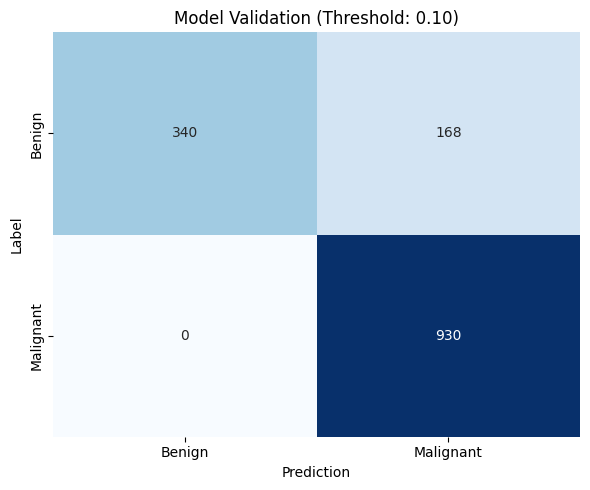

--- Dashboard for TH_T2_ClaD4N5_auc_f1_auc ---
Info     | Epoch:   N/A    | Threshold:  0.15 | LR: N/A
Loss     | Train:   N/A    | Validation: N/A  |
Metrics  | AUCROC: 0.9545  | F-1:  0.9247     | Acc: 0.8950
Score    | Recall: 0.9968  | Spec: 0.7087     | Total Images: 1438
Detected | TP:      927    | TN:   360        | Total Clears: 1287
Errors   | FN:      3      | FP:   148        | Total Errors: 151
----------------------------------------------------------------------


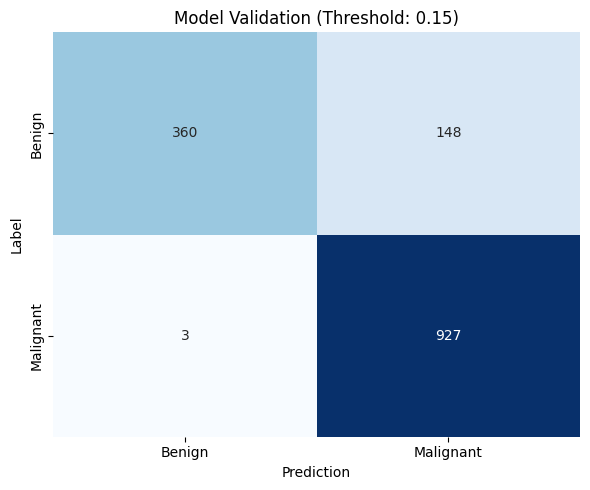

--- Dashboard for TH_T2_ClaD4N5_auc_f1_auc ---
Info     | Epoch:   N/A    | Threshold:  0.20 | LR: N/A
Loss     | Train:   N/A    | Validation: N/A  |
Metrics  | AUCROC: 0.9545  | F-1:  0.9267     | Acc: 0.8985
Score    | Recall: 0.9925  | Spec: 0.7264     | Total Images: 1438
Detected | TP:      923    | TN:   369        | Total Clears: 1292
Errors   | FN:      7      | FP:   139        | Total Errors: 146
----------------------------------------------------------------------


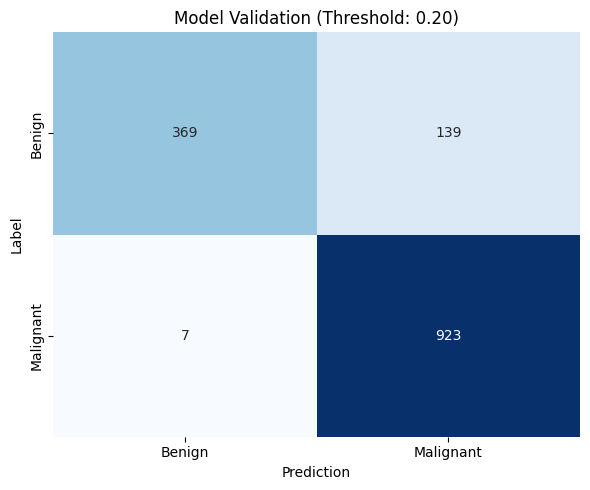

--- Dashboard for TH_T2_ClaD4N5_auc_f1_auc ---
Info     | Epoch:   N/A    | Threshold:  0.25 | LR: N/A
Loss     | Train:   N/A    | Validation: N/A  |
Metrics  | AUCROC: 0.9545  | F-1:  0.9290     | Acc: 0.9026
Score    | Recall: 0.9849  | Spec: 0.7520     | Total Images: 1438
Detected | TP:      916    | TN:   382        | Total Clears: 1298
Errors   | FN:      14     | FP:   126        | Total Errors: 140
----------------------------------------------------------------------


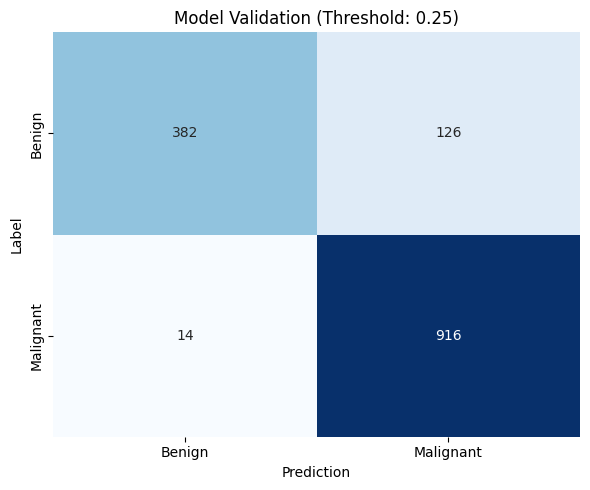

--- Dashboard for TH_T2_ClaD4N5_auc_f1_auc ---
Info     | Epoch:   N/A    | Threshold:  0.30 | LR: N/A
Loss     | Train:   N/A    | Validation: N/A  |
Metrics  | AUCROC: 0.9545  | F-1:  0.9320     | Acc: 0.9075
Score    | Recall: 0.9806  | Spec: 0.7736     | Total Images: 1438
Detected | TP:      912    | TN:   393        | Total Clears: 1305
Errors   | FN:      18     | FP:   115        | Total Errors: 133
----------------------------------------------------------------------


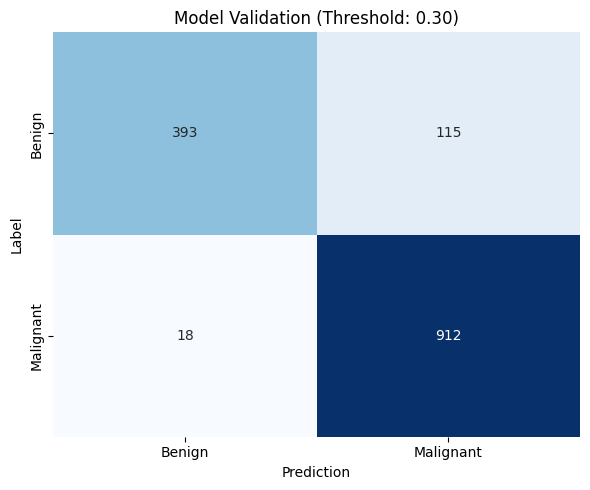

--- Dashboard for TH_T2_ClaD4N5_auc_f1_auc ---
Info     | Epoch:   N/A    | Threshold:  0.35 | LR: N/A
Loss     | Train:   N/A    | Validation: N/A  |
Metrics  | AUCROC: 0.9545  | F-1:  0.9310     | Acc: 0.9068
Score    | Recall: 0.9720  | Spec: 0.7874     | Total Images: 1438
Detected | TP:      904    | TN:   400        | Total Clears: 1304
Errors   | FN:      26     | FP:   108        | Total Errors: 134
----------------------------------------------------------------------


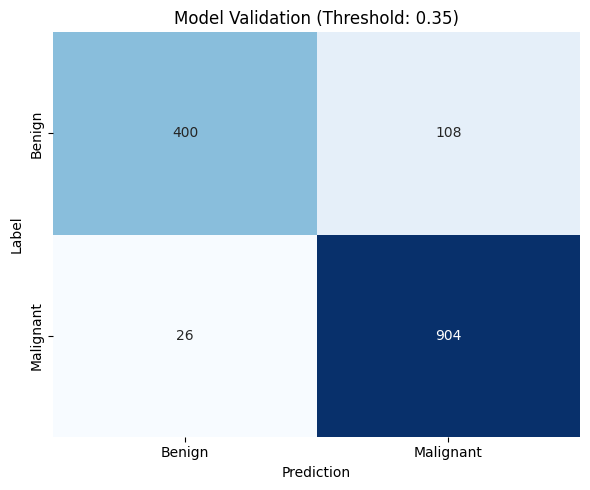

--- Dashboard for TH_T2_ClaD4N5_auc_f1_auc ---
Info     | Epoch:   N/A    | Threshold:  0.40 | LR: N/A
Loss     | Train:   N/A    | Validation: N/A  |
Metrics  | AUCROC: 0.9545  | F-1:  0.9299     | Acc: 0.9061
Score    | Recall: 0.9634  | Spec: 0.8012     | Total Images: 1438
Detected | TP:      896    | TN:   407        | Total Clears: 1303
Errors   | FN:      34     | FP:   101        | Total Errors: 135
----------------------------------------------------------------------


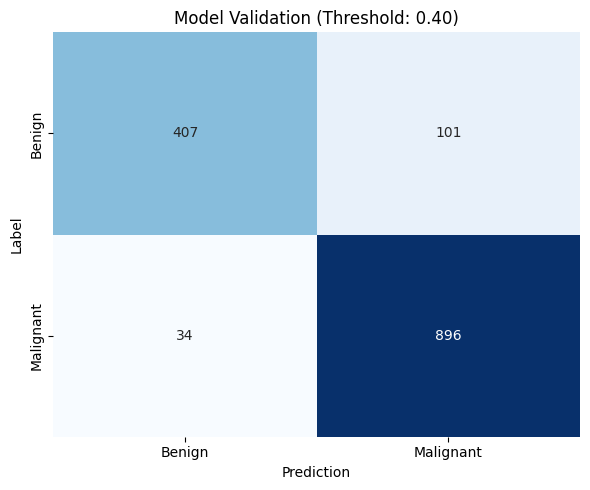

--- Dashboard for TH_T2_ClaD4N5_auc_f1_auc ---
Info     | Epoch:   N/A    | Threshold:  0.45 | LR: N/A
Loss     | Train:   N/A    | Validation: N/A  |
Metrics  | AUCROC: 0.9545  | F-1:  0.9284     | Acc: 0.9047
Score    | Recall: 0.9548  | Spec: 0.8130     | Total Images: 1438
Detected | TP:      888    | TN:   413        | Total Clears: 1301
Errors   | FN:      42     | FP:   95         | Total Errors: 137
----------------------------------------------------------------------


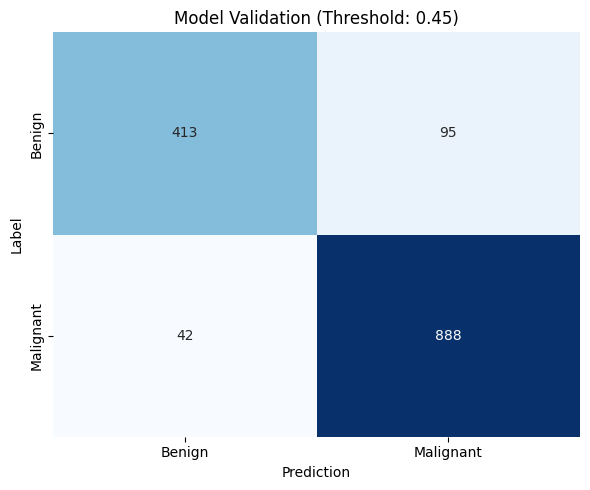

--- Dashboard for TH_T2_ClaD4N5_auc_f1_auc ---
Info     | Epoch:   N/A    | Threshold:  0.50 | LR: N/A
Loss     | Train:   N/A    | Validation: N/A  |
Metrics  | AUCROC: 0.9545  | F-1:  0.9263     | Acc: 0.9026
Score    | Recall: 0.9462  | Spec: 0.8228     | Total Images: 1438
Detected | TP:      880    | TN:   418        | Total Clears: 1298
Errors   | FN:      50     | FP:   90         | Total Errors: 140
----------------------------------------------------------------------


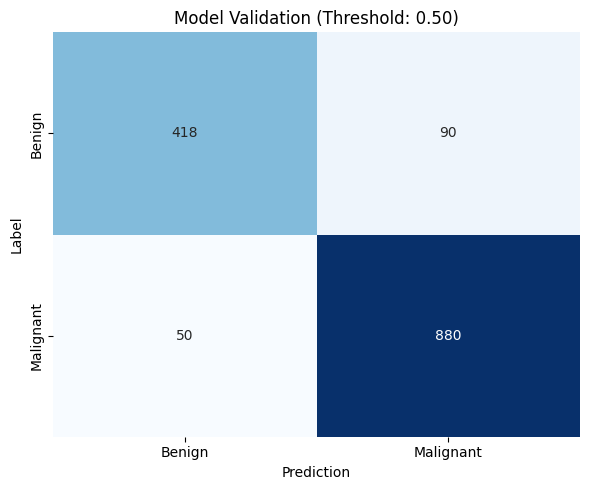

--- Dashboard for TH_T2_ClaD4N5_auc_f1_auc ---
Info     | Epoch:   N/A    | Threshold:  0.55 | LR: N/A
Loss     | Train:   N/A    | Validation: N/A  |
Metrics  | AUCROC: 0.9545  | F-1:  0.9231     | Acc: 0.8992
Score    | Recall: 0.9355  | Spec: 0.8327     | Total Images: 1438
Detected | TP:      870    | TN:   423        | Total Clears: 1293
Errors   | FN:      60     | FP:   85         | Total Errors: 145
----------------------------------------------------------------------


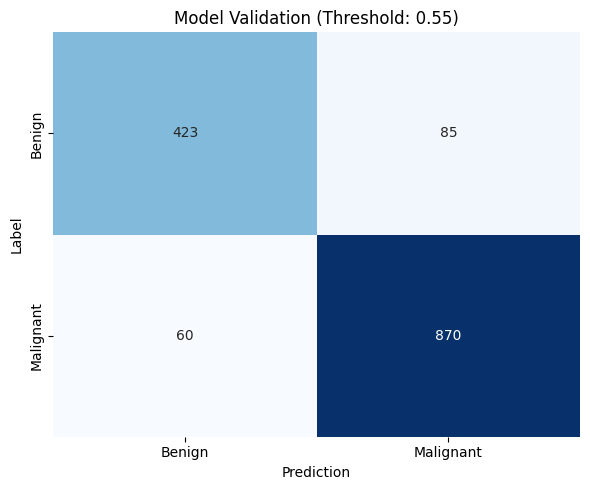

--- Dashboard for TH_T2_ClaD4N5_auc_f1_auc ---
Info     | Epoch:   N/A    | Threshold:  0.60 | LR: N/A
Loss     | Train:   N/A    | Validation: N/A  |
Metrics  | AUCROC: 0.9545  | F-1:  0.9237     | Acc: 0.9013
Score    | Recall: 0.9247  | Spec: 0.8583     | Total Images: 1438
Detected | TP:      860    | TN:   436        | Total Clears: 1296
Errors   | FN:      70     | FP:   72         | Total Errors: 142
----------------------------------------------------------------------


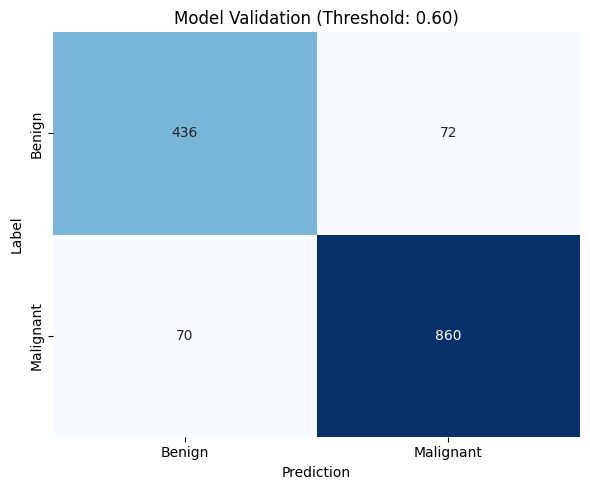

In [15]:
TTA_flag = True
thresh_start=0.1
thresh_end=0.6
step=0.05

model.eval()
all_labels = []
all_probs  = []

for inputs, labels in tqdm(test_loader, desc="Evaluating", leave=False):
    inputs = inputs.to(device)

    with torch.no_grad():
        outputs = model(inputs)
        if TTA_flag:
            img_hflip  = torch.flip(inputs, dims=[3])
            img_vflip  = torch.flip(inputs, dims=[2])
            img_rot90  = torch.rot90(inputs, k=1, dims=[2, 3])

            prob_orig  = torch.sigmoid(outputs)
            prob_hflip = torch.sigmoid(model(img_hflip))
            prob_vflip = torch.sigmoid(model(img_vflip))
            prob_rot90 = torch.sigmoid(model(img_rot90))

            probs = (prob_orig + prob_hflip + prob_vflip + prob_rot90) / 4.0
        else:
            probs = torch.sigmoid(outputs)

    all_labels.extend(labels.cpu().numpy())
    all_probs.extend(probs.cpu().numpy())

all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

auc = roc_auc_score(all_labels, all_probs)

thresholds = np.arange(thresh_start, thresh_end + (step / 2), step)

for thresh in thresholds:
    preds = (all_probs >= thresh).astype(int)
    acc = accuracy_score(all_labels, preds)
    f1 = f1_score(all_labels, preds, zero_division=0)
    recall = recall_score(all_labels, preds, zero_division=0)
    cm = confusion_matrix(all_labels, preds, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    TC = tn + tp
    TE = fn + fp
    TI = TC + TE
    specificity = tn / (tn + fp)

    print(f"--- Dashboard for {model_name} ---")
    print(f"Info     | Epoch:   N/A    | Threshold:  {thresh:.2f} | LR: N/A")
    print(f"Loss     | Train:   N/A    | Validation: N/A  |")
    print(f"Metrics  | AUCROC: {auc:.4f}  | F-1:  {f1:.4f}     | Acc: {acc:.4f}")
    print(f"Score    | Recall: {recall:.4f}  | Spec: {specificity:.4f}     | Total Images: {TI}")
    print(f"Detected | TP:      {tp:<4}   | TN:   {tn:<3}        | Total Clears: {TC}")
    print(f"Errors   | FN:      {fn:<4}   | FP:   {fp:<3}        | Total Errors: {TE}")
    print("-" * 70)

    #Plot the Visual Heatmap
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["Benign", "Malignant"],
                yticklabels=["Benign", "Malignant"])
    plt.title(f"Model Validation (Threshold: {thresh:.2f})")
    plt.ylabel('Label')
    plt.xlabel('Prediction')
    plt.tight_layout()
    plt.show()